In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tracemalloc
from scipy.ndimage import gaussian_filter
from tqdm.auto import tqdm
import plotting_config

from ummd import MMD

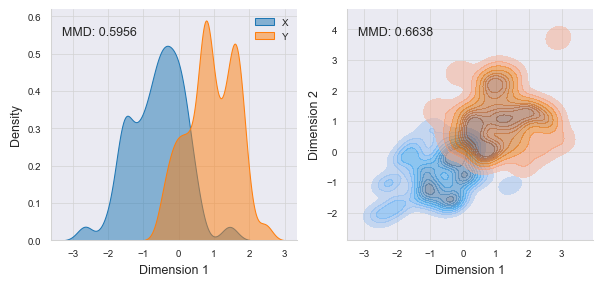

In [2]:
def create_repeated_sample(N, u, d=1):
    rng = np.random.default_rng(seed=42)
    half = N // 2
    n_total = max(2, round(N * u))
    nx = n_total - n_total // 2
    ny = n_total // 2

    Xu = rng.normal(-0.7, 1.0, (nx, d))
    Yu = rng.normal( 1.1, 0.9, (ny, d))

    X = Xu[np.arange(half) % nx]
    Y = Yu[np.arange(half) % ny]

    n = np.unique(X, axis=0).shape[0] + np.unique(Y, axis=0).shape[0]
    assert n == n_total, f"Expected {n_total} unique samples, but got {n}"
    return X, Y


fig, axes = plt.subplots(1, 2, figsize=(7, 3))

# 1D
X, Y = create_repeated_sample(1000, 0.1, d=1)
sns.kdeplot(x=X.reshape(-1), fill=True, alpha=0.5, label="X", ax=axes[0])
sns.kdeplot(x=Y.reshape(-1), fill=True, alpha=0.5, label="Y", ax=axes[0])
axes[0].set_xlabel('Dimension 1'); axes[0].legend()
mmd_value = MMD(X, Y, unique=True, bandwidths='median', n_permutations=999)['biased_MMD'][0]
axes[0].text(0.2, 0.9, f"MMD: {mmd_value:.4f}", transform=axes[0].transAxes, ha='center', va='center', fontsize=9)


# 2D
X, Y = create_repeated_sample(1000, 0.1, d=2)
sns.kdeplot(x=X[:, 0], y=X[:, 1], fill=True, alpha=0.5, label="X", ax=axes[1])
sns.kdeplot(x=Y[:, 0], y=Y[:, 1], fill=True, alpha=0.5, label="Y", ax=axes[1])
axes[1].set_xlabel('Dimension 1'); axes[1].set_ylabel('Dimension 2'); axes
mmd_value = MMD(X, Y, unique=True, bandwidths='median', n_permutations=999)['biased_MMD'][0]
axes[1].text(0.2, 0.9, f"MMD: {mmd_value:.4f}", transform=axes[1].transAxes, ha='center', va='center', fontsize=9)
sns.despine(); plt.show()

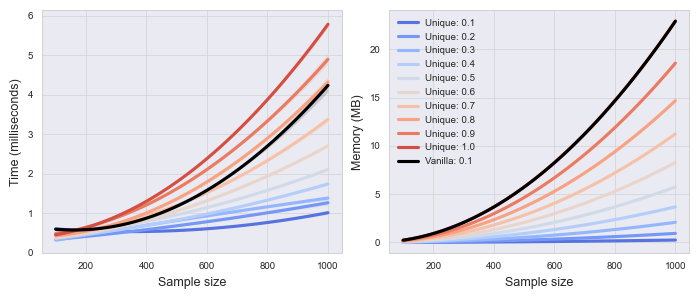

In [3]:
U = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
N = np.arange(100, 1001, 10)

colors = sns.palettes.color_palette("coolwarm", n_colors=len(U))

unique_stats = {
    u: { "time": [], "memory": [], "vanilla_time": [], "vanilla_memory": []} for u in U
}

for u in U:
    for n in N:
        X, Y = create_repeated_sample(n, u, d=1)

        # Unique
        tracemalloc.start()
        MMD(X, Y, unique=True, bandwidths='median', n_permutations=0)
        _, peak = tracemalloc.get_traced_memory()
        unique_stats[u]["memory"].append(peak/1024/1024)
        tracemalloc.stop()
        unique_stats[u]["time"].append(MMD.time_taken*1000)
        
        # Vanilla
        tracemalloc.start()
        MMD(X, Y, unique=False, bandwidths='median', n_permutations=0)
        _, peak = tracemalloc.get_traced_memory()
        unique_stats[u]["vanilla_memory"].append(peak/1024/1024)      
        tracemalloc.stop()
        unique_stats[u]["vanilla_time"].append(MMD.time_taken*1000)



fig, axes = plt.subplots(1, 2, figsize=(7, 3))
for i, u in enumerate(U):
    sns.regplot(x=N, y=unique_stats[u]["time"], label=f"Unique: {u}", marker="o", order=2, color=colors[i], scatter=None, ax=axes[0])
sns.regplot(x=N, y=unique_stats[0.1]["vanilla_time"], label=f"Vanilla: {0.1}", marker="o", order=2, color='black', scatter=None, ax=axes[0])
axes[0].set_xlabel("Sample size")
axes[0].set_ylabel("Time (milliseconds)")

for i, u in enumerate(U):
    sns.regplot(x=N, y=unique_stats[u]["memory"], label=f"Unique: {u}", order=2, color=colors[i], scatter=None, ax=axes[1])
sns.regplot(x=N, y=unique_stats[0.1]["vanilla_memory"], label=f"Vanilla: {0.1}", order=2, color='black', scatter=None, ax=axes[1])
axes[1].set_xlabel("Sample size")
axes[1].set_ylabel("Memory (MB)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [4]:
U = np.arange(0.01, 1.02, 0.1).clip(0, 1)
N = np.arange(100, 1001, 100)
B = [0, 9, 99, 999, 9999]
L = [1, 2, 5, 10, 20]
b = [9, 99, 999] # If testing permutation batch size effects


t_heatmaps = np.empty((len(B), len(L)), dtype=object)
m_heatmaps = np.empty((len(B), len(L)), dtype=object)

for b_idx, b in tqdm(enumerate(B), total=len(B), position=0, desc="Total progress"):
    for l_idx, l in tqdm(enumerate(L), total=len(L), leave=False, position=1, desc="Bandwidths"):

        t_heatmap = np.empty((len(U), len(N)))
        m_heatmap = np.empty((len(U), len(N)))

        for i in tqdm(range(len(U)), leave=False, position=2, desc=f"Uniqueness"):
            for j in tqdm(range(len(N)), leave=False, position=3, desc=f"Sample sizes"):
                X, Y = create_repeated_sample(N[j], U[i], d=2)

                # Unique
                tracemalloc.start()
                MMD(X, Y, unique=True, bandwidths=l, n_permutations=b, perm_batch_size=b)
                _, peak = tracemalloc.get_traced_memory()
                m_heatmap[i, j] = peak/1024/1024      
                tracemalloc.stop()
                t_heatmap[i, j] = MMD.time_taken*1000

                # Vanilla
                tracemalloc.start()
                MMD(X, Y, unique=False, bandwidths=l, n_permutations=b, perm_batch_size=b)
                _, peak = tracemalloc.get_traced_memory()
                m_heatmap[i, j] /= peak/1024/1024
                tracemalloc.stop()
                t_heatmap[i, j] /= MMD.time_taken*1000

        t_heatmaps[b_idx, l_idx] = gaussian_filter(np.log2(t_heatmap), sigma=3)
        m_heatmaps[b_idx, l_idx] = gaussian_filter(np.log2(m_heatmap), sigma=3)

Total progress:   0%|          | 0/5 [00:00<?, ?it/s]

Bandwidths:   0%|          | 0/5 [00:00<?, ?it/s]

Uniqueness:   0%|          | 0/11 [00:00<?, ?it/s]

Sample sizes:   0%|          | 0/10 [00:00<?, ?it/s]

Sample sizes:   0%|          | 0/10 [00:00<?, ?it/s]

...

Sample sizes:   0%|          | 0/10 [00:00<?, ?it/s]

Sample sizes:   0%|          | 0/10 [00:00<?, ?it/s]

Sample sizes:   0%|          | 0/10 [00:00<?, ?it/s]

Sample sizes:   0%|          | 0/10 [00:00<?, ?it/s]

Sample sizes:   0%|          | 0/10 [00:00<?, ?it/s]

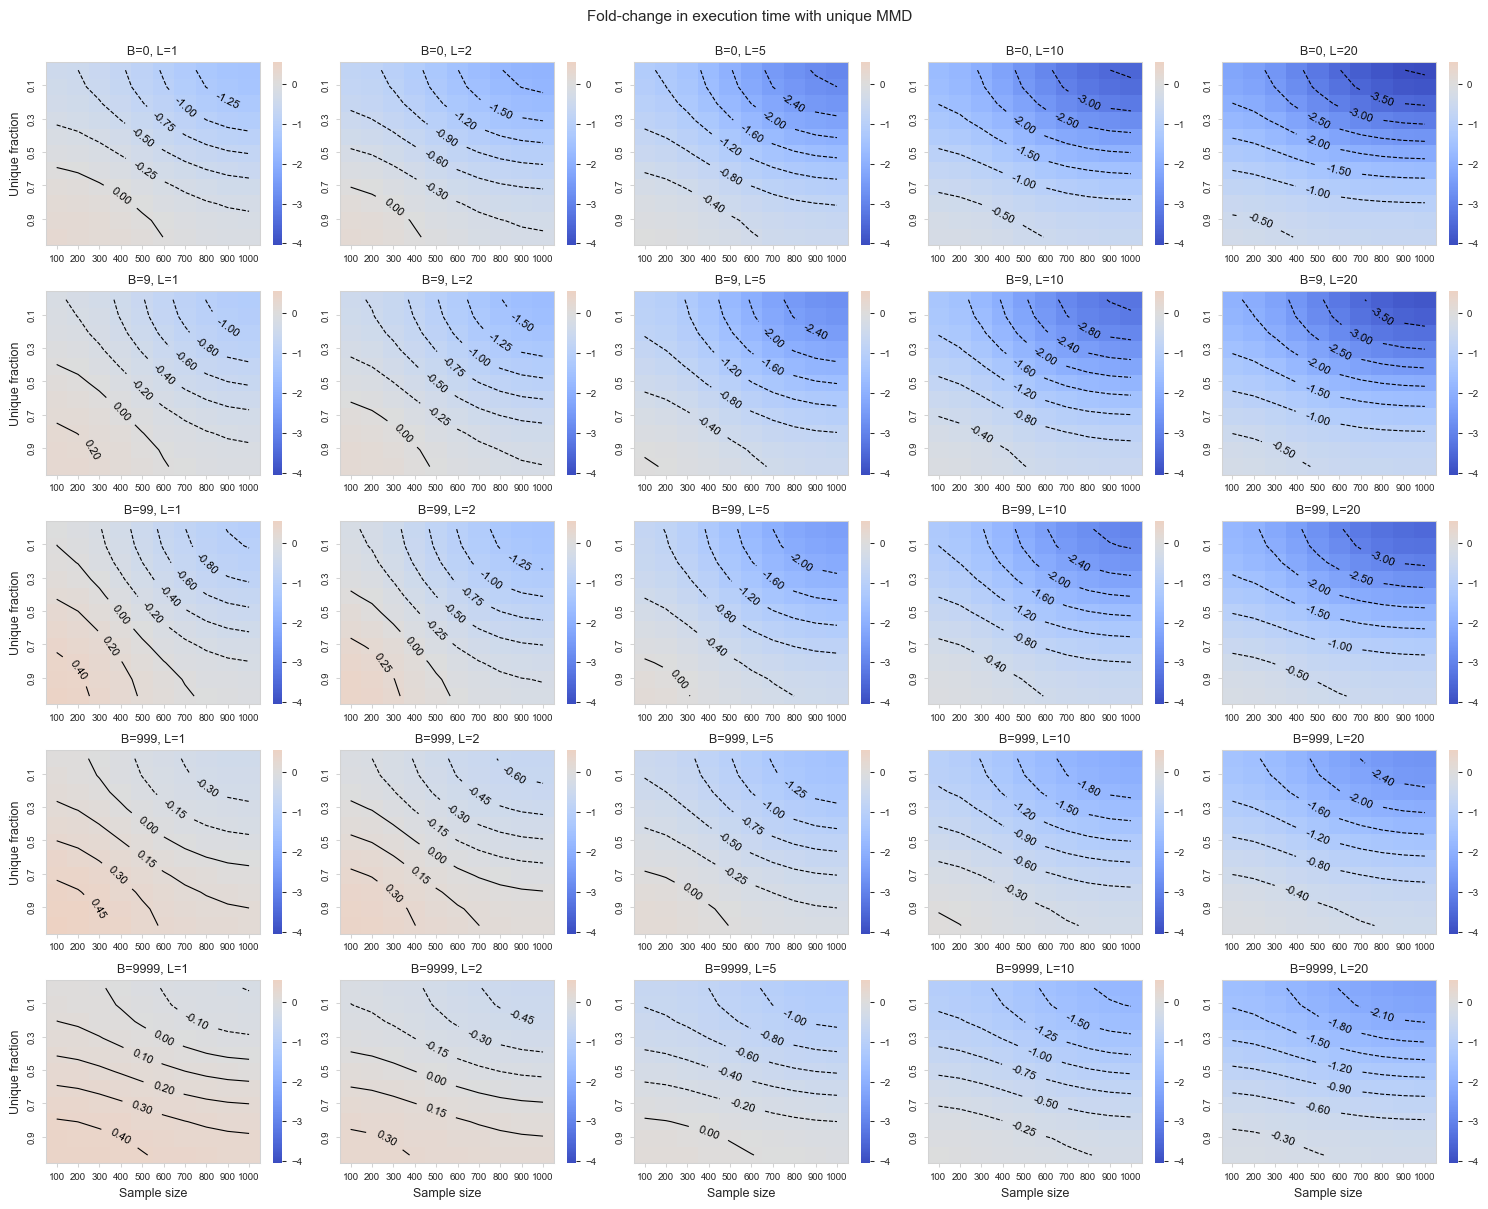

In [5]:
def plot_heatmap_grid(title, heatmaps, save_path=None):

    # For determining cmap max and min across trials
    all_vals = np.concatenate([h.ravel() for h in heatmaps.flat])


    fig, axes = plt.subplots(len(B), len(L), figsize=(len(B)*3, len(L)*2.4))
    for i in range(len(B)):
        for j in range(len(L)):
            ax = axes[i, j]
            sns.heatmap(heatmaps[i, j], cmap="coolwarm", center=0, vmin=all_vals.min(), vmax=all_vals.max(),ax=ax)

            # contour grid offset by 0.5 to sit at heatmap cell centers
            X, Y = np.meshgrid(np.arange(heatmaps[i, j].shape[1]) + 0.5, np.arange(heatmaps[i, j].shape[0]) + 0.5)
            cs = ax.contour(X, Y, heatmaps[i, j], colors="black", linewidths=0.8)
            ax.clabel(cs, inline=True, fontsize=8, fmt="%.2f")

            # Ticks and plot aesthetics
            xt = np.arange(100, 1001, 100)
            ax.set_xticks(np.interp(xt, N, np.arange(len(N)) + .5), xt)
            yt = np.arange(0.1, 1.01, 0.2)
            ax.set_yticks(np.interp(yt, U, np.arange(len(U)) + .5), [f"{v:.1f}" for v in yt])
            if j==0:
                ax.set_ylabel("Unique fraction")
            if i==len(B)-1:
                ax.set_xlabel("Sample size")
            ax.set_title(f"B={B[i]}, L={L[j]}")
            ax.tick_params(bottom=True, left=True, color='lightgrey')
            ax.spines[['top','right','bottom','left']].set_visible(True)
            
    plt.suptitle(title, y=1.0)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()

plot_heatmap_grid("Fold-change in execution time with unique MMD", t_heatmaps, save_path="time_heatmap_grid.svg")

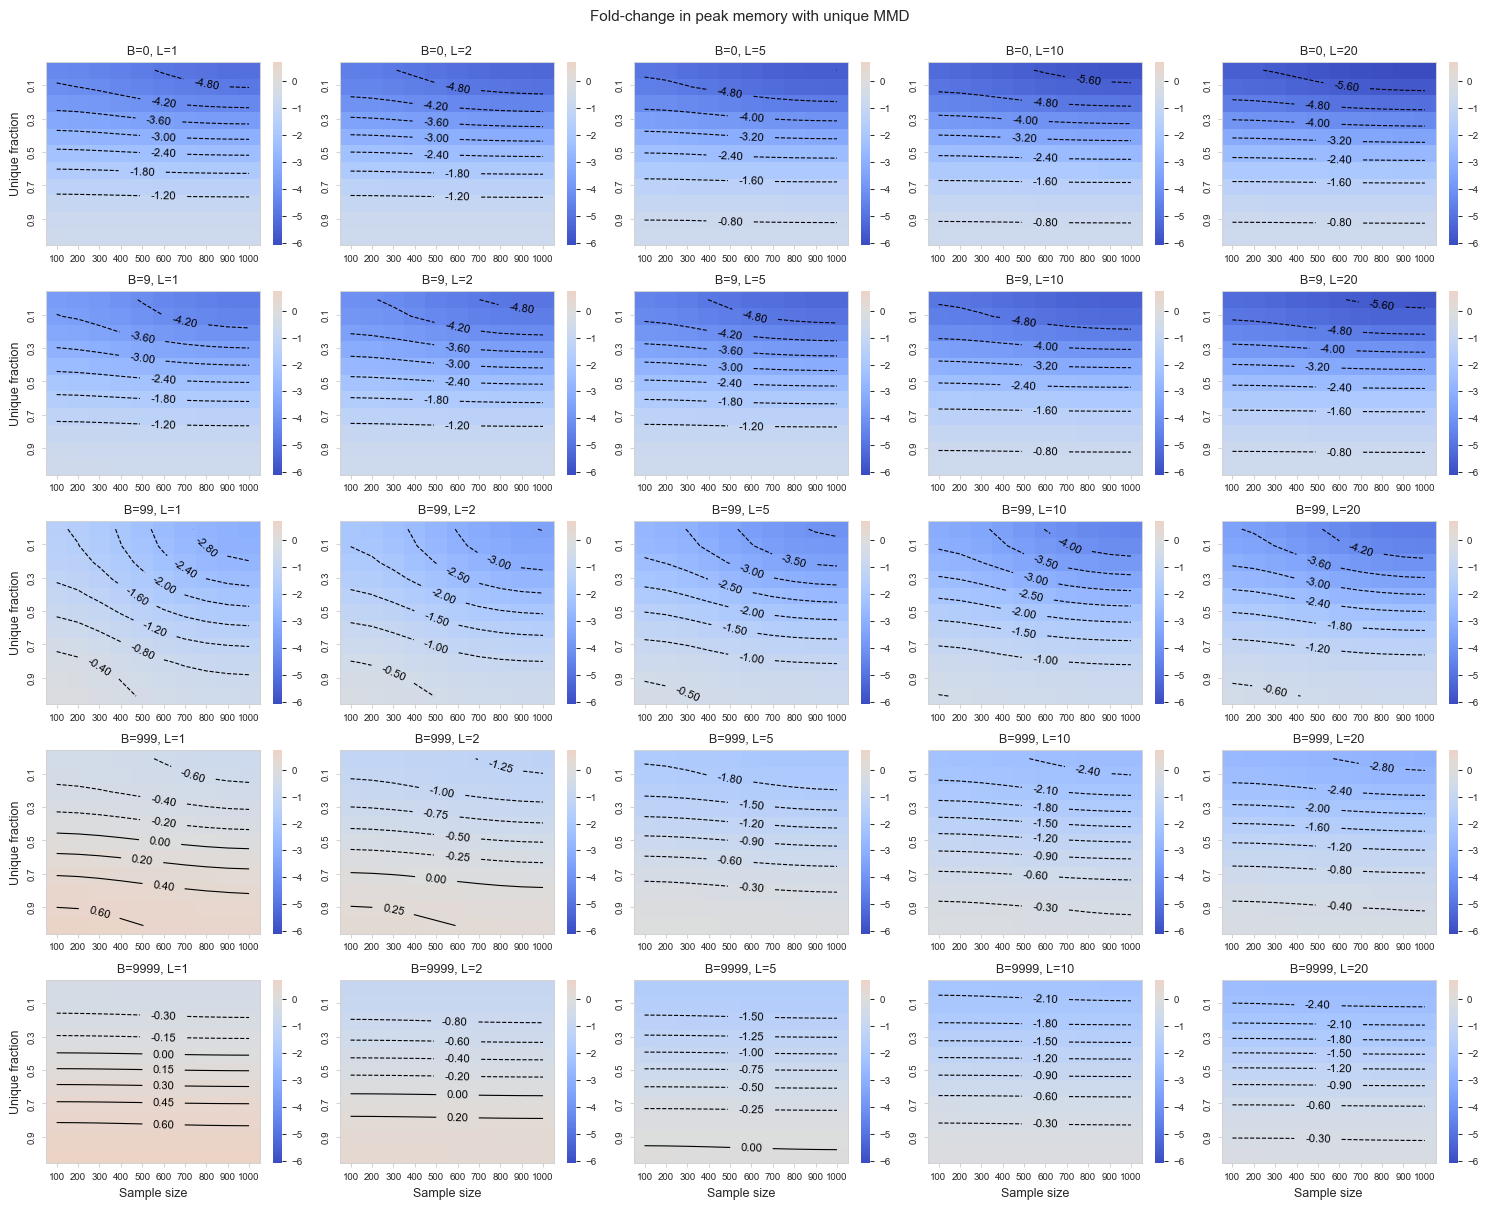

In [6]:
plot_heatmap_grid("Fold-change in peak memory with unique MMD", m_heatmaps, save_path="memory_heatmap_grid.svg")

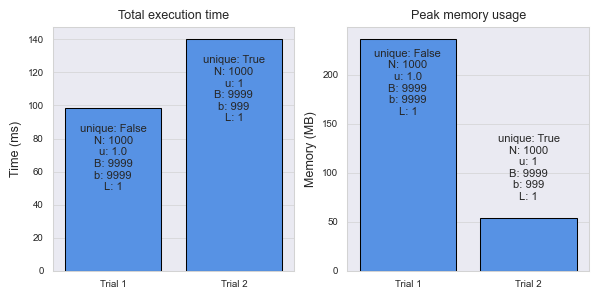

In [7]:
# Edit parameters below to compare space and time performance across two trials
config ={
    'Trial 1' : {
        'unique': False,
        'N': 1000,
        'u': 1.0,
        'B': 9999,
        'b': 9999,
        'L': 1,
    },
    'Trial 2' : {
        'unique': True,
        'N': 1000,
        'u': 1,
        'B': 9999,
        'b': 999,
        'L': 1,
    }
}

# Trial 1
X, Y = create_repeated_sample(config['Trial 1']['N'], config['Trial 1']['u'])
tracemalloc.start()
MMD(X, Y, unique=config['Trial 1']['unique'], bandwidths=config['Trial 1']['L'], n_permutations=config['Trial 1']['B'], perm_batch_size=config['Trial 1']['b'])
_, peak = tracemalloc.get_traced_memory()
trial1_mb = peak/1024/1024
trial1_ms = MMD.time_taken*1000
tracemalloc.stop() 

# Trial 2
X, Y = create_repeated_sample(config['Trial 2']['N'], config['Trial 2']['u'])
tracemalloc.start()
MMD(X, Y, unique=config['Trial 2']['unique'], bandwidths=config['Trial 2']['L'], n_permutations=config['Trial 2']['B'], perm_batch_size=config['Trial 2']['b'])
_, peak = tracemalloc.get_traced_memory()   
trial2_mb = peak/1024/1024
trial2_ms = MMD.time_taken*1000
tracemalloc.stop()


fig, axes = plt.subplots(1, 2, figsize=(6, 3))
# Positioning text labels
multiplier = lambda trial1, trial2: 1 if trial1 < max(trial1, trial2)/2 else -2
va       = lambda trial1, trial2: 'bottom' if trial1 < max(trial1, trial2)/2 else 'top'

# Time
sns.barplot(x=['Trial 1', 'Trial 2'], y=[trial1_ms, trial2_ms], edgecolor='black', ax=axes[0], color='#3f8efc')
axes[0].text(0, trial1_ms + multiplier(trial1_ms, trial2_ms)*5, "".join([f"{key}: {value}\n" for key, value in config['Trial 1'].items()]), ha='center', va=va(trial1_ms, trial2_ms), fontsize=8)
axes[0].text(1, trial2_ms + multiplier(trial2_ms, trial1_ms)*5, "".join([f"{key}: {value}\n" for key, value in config['Trial 2'].items()]), ha='center', va=va(trial2_ms, trial1_ms), fontsize=8)
axes[0].set_ylabel("Time (ms)")
axes[0].set_title("Total execution time")

# Space
sns.barplot(x=['Trial 1', 'Trial 2'], y=[trial1_mb, trial2_mb], edgecolor='black', ax=axes[1], color='#3f8efc')
axes[1].text(0, trial1_mb + multiplier(trial1_mb, trial2_mb)*5, "".join([f"{key}: {value}\n" for key, value in config['Trial 1'].items()]), ha='center', va=va(trial1_mb, trial2_mb), fontsize=8)
axes[1].text(1, trial2_mb + multiplier(trial2_mb, trial1_mb)*5, "".join([f"{key}: {value}\n" for key, value in config['Trial 2'].items()]), ha='center', va=va(trial2_mb, trial1_mb), fontsize=8)
axes[1].set_ylabel("Memory (MB)")
axes[1].set_title("Peak memory usage")

plt.tight_layout()
plt.show()